Reissner Mindlin Plate : Modal Analysis with Fenicsx 
=================

First of all, this work is base on Jeremie Bleyer's work which can be found with this link : [Fenicsx Tour : Reissner-Mindlin plates ](https://bleyerj.github.io/comet-fenicsx/intro/plates/plates.html)

Governor Equation
===============

Generalized strain
---------------

- Courbure : $ \chi = \nabla^S \phi  $
- Déformation de cisaillement : $ \gamma = \nabla u - \phi $

Generalized stresses
----------------

- Moment lié à la courbure : $ \textbf{M} $
- Force de cisaillement : $ \textbf{V} $ 

Formulation Forte 
----------------

 - $ V_{ \beta , \beta } = M \ddot U_3 $
 - $ M_{ \alpha \beta , \beta } - V_\alpha = I \ddot \phi _\alpha $

Implementation Start 
-----------------
Importation des bibliothéque utile

In [62]:
import numpy as np
import ufl
import basix

from mpi4py import MPI
from dolfinx import fem, io
import dolfinx.fem.petsc
from dolfinx.fem import Constant, dirichletbc, Function, functionspace, locate_dofs_topological
import dolfinx.mesh
from dolfinx.io import XDMFFile

Implentation des paramétres de la plaque étudié

In [63]:
L  = 0.09981 # Longueur de la plaque
W_dim = 0.0502 # Largeur de la plaque
N = 30 # Nombre de subdivision de la plaque
domain = dolfinx.mesh.create_rectangle(
    MPI.COMM_WORLD, [[0, 0], [L, W_dim]], [N, N] , cell_type=dolfinx.mesh.CellType.quadrilateral
) # Création du "mesh" de la plaque elle nous servira tous le long du programme pour appeler notre forme

gdim = domain.geometry.dim

# material parameters
thick = 0.00104 # épaisseur de la plaque
E = 70.08e9 # Module de Young du matériaus [MPa]
nu = 0.30 # Coef de poisson du matériau
rho = 2700.0 # Masse volumique [kg/L]

## Création des des matrices et des constantes :
- Matrice des Moments
$$
\mathbf{D} = D \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix} 
\quad \text{avec} \quad 
D = \frac{E \times h^3}{12(1-\nu^2)}
$$
- Constante des efforts de cisaillement
$$
F = \frac{5}{6} \times \frac{E \times h}{2(1 + \nu)}
$$
- Matrice de Masse
$$
\mathbf{M} = M \begin{bmatrix}
1 & 0 & 0 \\
0 & \frac{h^2}{12} & 0 \\
0 & 0 & \frac{h^2}{12}
\end{bmatrix}
\quad \text{avec} \quad
M = \rho h
$$

- Matrice des précontraintes

$$
\begin{aligned}
\underline{\underline{L}} &= \int_h \underline{\underline{\tilde{\sigma}}}(z) z^2 \, dz \\
\underline{\underline{P}} &= \int_h \underline{\underline{\tilde{\sigma}}}(z) \, dz
\end{aligned}
\qquad \text{donc} \qquad
\underset{\approx}{\Omega} = \begin{bmatrix}
\underline{\underline{P}} & 0 & 0 \\
0 & \underline{\underline{L}} & 0 \\
0 & 0 & \underline{\underline{L}}
\end{bmatrix}
$$

In [65]:
# bending stiffness
D = fem.Constant(domain, E * thick**3 / (1 - nu**2) / 12.0)
# shear stiffness
F = fem.Constant(domain, E / 2 / (1 + nu) * thick * 5.0 / 6.0)
# Inertilal constant
M = fem.Constant(domain , rho * thick)
# Acousto-Elastic Constants
sig0 = 0.0e6 # Pre-stress in the plate [Pa]
P = fem.Constant(domain, sig0 * thick)
L_m = fem.Constant(domain, sig0 * thick**3 / 12.0)

def curvature(u):
    (w, theta) = ufl.split(u)
    return ufl.as_vector(
        [theta[0].dx(0), theta[1].dx(1), theta[0].dx(1) + theta[1].dx(0)]
    )

def shear_strain(u):
    (w, theta) = ufl.split(u)
    return ufl.grad(w) - theta


def bending_moment(u):
    DD = ufl.as_matrix([[D, nu * D, 0], [nu * D, D, 0], [0, 0, D * (1 - nu) / 2.0]])
    return ufl.dot(DD, curvature(u))

def inertial(u) :
    MM = ufl.as_matrix([[M, 0, 0], [0, M*thick**2/12, 0], [0, 0, M*thick**2/12]])
    return ufl.dot(MM, u)


def shear_force(u):
    return F * shear_strain(u)


def residual_stress_shear(u, v) : 
    """Énergie de précontrainte (cisaillement)"""
    (dw, dtheta) = ufl.split(u)
    (w_, theta_) = ufl.split(v)
    
    return P * ufl.dot(ufl.grad(dw), ufl.grad(w_))

def residual_stress_bending(u, v):
    """Énergie de précontrainte (flexion)"""
    (dw, dtheta) = ufl.split(u)
    (w_, theta_) = ufl.split(v)
    
    return L_m * ufl.inner(ufl.grad(dtheta), ufl.grad(theta_))

On crée un vecteur avec 1 déplacement vertical et 2 rotation autour de la courbure :

$U_e = U_3$

$T_e = \begin{bmatrix} \phi_1  \\ \phi_2 \end{bmatrix} $

In [66]:

Ue = basix.ufl.element("Q", domain.basix_cell(), 2)
Te = basix.ufl.element("Q", domain.basix_cell(), 1, shape=(2,))
V = fem.functionspace(domain, basix.ufl.mixed_element([Ue, Te]))

Création des fonctions pour la formulation faible 

In [67]:
u = fem.Function(V, name="Unknown")
u_ = ufl.TestFunction(V)
(w_, theta_) = ufl.split(u_)
du = ufl.TrialFunction(V)
(dw , dtheta) = ufl.split(du)

Définition de la formulation Faible

In [68]:
dx = ufl.Measure("dx", domain=domain)
L = fem.Constant(domain, 0.0) * w_ * dx

# On définit la forme de raideur K complète
a = (
    ufl.inner(bending_moment(du), curvature(u_))
    + ufl.inner(shear_force(du), shear_strain(u_))
    + residual_stress_bending(du, u_) 
    + residual_stress_shear(du, u_)
) * dx

Définition des conditions aux limites de la plaque

In [69]:
def border(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], 0))

facet_dim = 1
clamped_facets = dolfinx.mesh.locate_entities_boundary(domain, facet_dim, border)
clamped_dofs = fem.locate_dofs_topological(V, facet_dim, clamped_facets)

u0 = fem.Function(V)
bcs = []

Résolution du probléme Linéaire : Optionnel

In [70]:
from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a, L, u=u, bcs=bcs, petsc_options={"ksp_type": "preonly", "pc_type": "lu"}, petsc_options_prefix="Plate"
)
problem.solve()

with io.VTKFile(domain.comm, "plates.xdmf", "w") as vtk:
    w = u.sub(0).collapse()
    w.name = "Deflection"
    vtk.write_function(w)

Affichage de la solution du probléme Linéaire

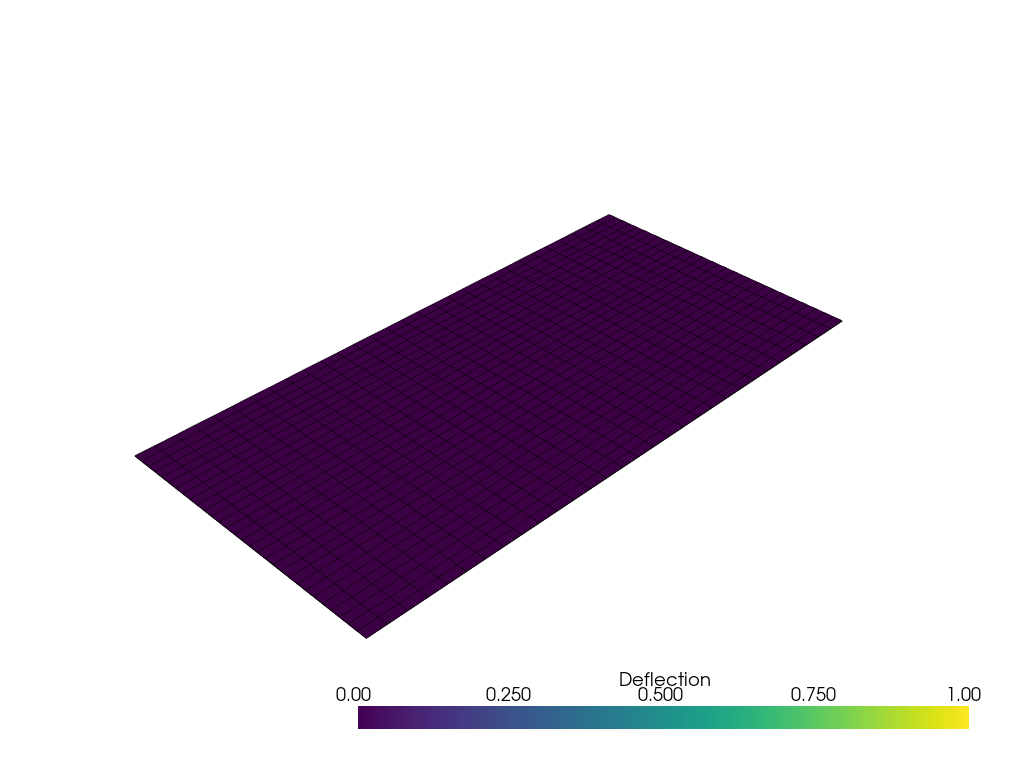

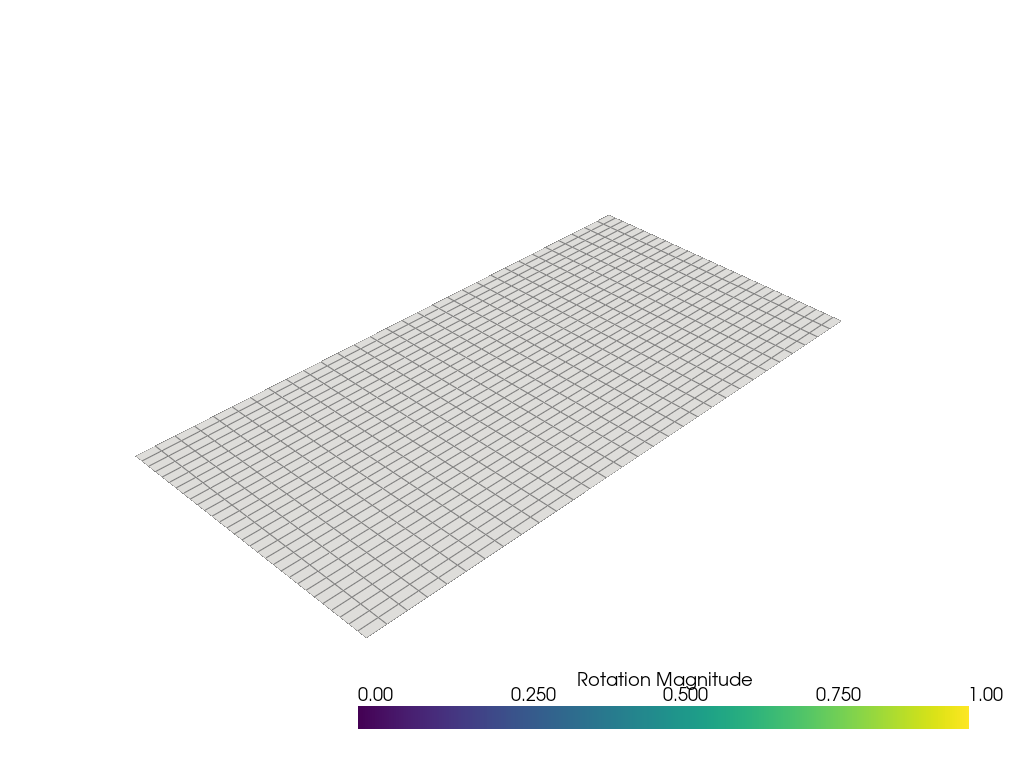

In [71]:
import pyvista
from dolfinx import plot

pyvista.set_jupyter_backend('static')

Vw = w.function_space
w_topology, w_cell_types, w_geometry = plot.vtk_mesh(Vw)
w_grid = pyvista.UnstructuredGrid(w_topology, w_cell_types, w_geometry)
w_grid.point_data["Deflection"] = w.x.array
w_grid.set_active_scalars("Deflection")
warped = w_grid.warp_by_scalar("Deflection", factor=5)

plotter = pyvista.Plotter()
plotter.add_mesh(
    warped,
    show_scalar_bar=True,
    scalars="Deflection",
)
edges = warped.extract_all_edges()
plotter.add_mesh(edges, color="k", line_width=1)
plotter.show()

theta = u.sub(1).collapse()
Vt = theta.function_space
theta_topology, theta_cell_types, theta_geometry = plot.vtk_mesh(Vt)
theta_grid = pyvista.UnstructuredGrid(theta_topology, theta_cell_types, theta_geometry)
beta_3D = np.zeros((theta_geometry.shape[0], 3))
beta_3D[:, :2] = theta.x.array.reshape(-1, 2) @ np.array([[0, -1], [1, 0]])
theta_grid["beta"] = beta_3D
theta_grid.set_active_vectors("beta")
"""
"""
plotter = pyvista.Plotter()
plotter.add_mesh(
    theta_grid.arrows, lighting=False, scalar_bar_args={"title": "Rotation Magnitude"}
)
plotter.add_mesh(theta_grid, color="grey", ambient=0.6, opacity=0.5, show_edges=True)
plotter.show()

Analyse Modale du probléme 
-------
Dans cette partie nous allons résoudre l'équation :

$ KV - \lambda MV = 0 $

On récupérera les fréquences propres gràce à $ \lambda = \omega ^2 $ et $ \omega = 2 \pi f $

Définition de la Matrice de masse en formulation faible et assemblage des matrices de Masse et de raideur

In [72]:
m_form =  ufl.dot(inertial(u_), du) * dx

K = fem.petsc.assemble_matrix(fem.form(a), bcs)
K.assemble()
M = fem.petsc.assemble_matrix(fem.form(m_form), bcs)
M.assemble()

Solver du probléme aux modes propres

In [73]:
from petsc4py import PETSc
from slepc4py import SLEPc

N_eig = 50
eigensolver = SLEPc.EPS().create(MPI.COMM_WORLD)
eigensolver.setDimensions(N_eig)
eigensolver.setProblemType(SLEPc.EPS.ProblemType.GHEP)
st = SLEPc.ST().create(MPI.COMM_WORLD)
st.setType(SLEPc.ST.Type.SINVERT)
st.setShift(0.1)
st.setFromOptions()
eigensolver.setST(st)
eigensolver.setOperators(K, M)
eigensolver.setFromOptions()

# Compute eigenvalue-eigenvector pairs
eigensolver.solve()
evs = eigensolver.getConverged()
vr, vi = K.getVecs()
u_output = Function(V)
u_output.name = "Eigenvector"
evs = eigensolver.getConverged()
print(f"Nombre de modes convergés : {evs}")

Nombre de modes convergés : 55


Trouvé l'ensemble des solutions :

In [74]:
import pyvista
import numpy as np

pyvista.set_jupyter_backend('trame')

# Choix du mode à afficher (ex: 3, 4, 5... pour sauter les modes de corps rigide)
mode_cible = 4

# Vérification que le mode demandé a bien été calculé
if mode_cible < evs:
    # 1. Récupération de la valeur propre et calcul de la fréquence
    l = eigensolver.getEigenpair(mode_cible, vr, vi)
    freq = np.sqrt(max(0, l.real)) / (2 * np.pi)
    
    # 2. Extraction sécurisée de la déflexion w
    u_output.x.array[:] = vr.getArray()
    u_output.x.scatter_forward()
    w_mode = u_output.sub(0).collapse()
    
    # 3. Création du maillage PyVista
    topology, cell_types, geometry = plot.vtk_mesh(w_mode.function_space)
    grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
    
    # Normalisation pour l'affichage (max amplitude = 1)
    w_array = w_mode.x.array
    grid.point_data["Amplitude"] = w_array / np.max(np.abs(w_array))
    warped = grid.warp_by_scalar("Amplitude", factor=0.05)
    
    # 4. Configuration et affichage de la fenêtre unique
    plotter = pyvista.Plotter(window_size=[1000, 700])
    plotter.set_background("white")
    plotter.add_text(
                    f"Mode {mode_cible} : {freq:.1f} Hz", 
                    position="lower_edge", 
                    font_size=14, 
                    color="black"
                    )
    plotter.add_mesh(warped, cmap="jet", show_scalar_bar=False , lighting=False)
    plotter.add_mesh(warped.extract_all_edges(), color="black", opacity=0.1)
    plotter.view_xy()
    plotter.enable_parallel_projection()
    plotter.show()
else:
    print(f"Le mode {mode_cible} n'a pas été calculé. Modes convergés : {evs}")

Widget(value='<iframe src="http://localhost:41961/index.html?ui=P_0x7c15e573d090_19&reconnect=auto" class="pyv…

Affichage des différents mode :
----


In [75]:
import numpy as np
# Vérification que le mode demandé a bien été calculé

mode = np.linspace(3, evs, evs, dtype=int)
freq_ha = []

# 1. Récupération de la valeur propre et calcul de la fréquence
for m in mode[:-2] :
    l = eigensolver.getEigenpair(m, vr, vi)
    freq = np.sqrt(max(0, l.real)) / (2 * np.pi)
    freq_ha.append(freq)

print(freq_ha)

[np.float64(549.8405846367596), np.float64(549.8405846367596), np.float64(674.3837933028608), np.float64(1486.0326724180325), np.float64(1527.7124608397112), np.float64(2226.455082959312), np.float64(2584.3169248828403), np.float64(2630.294630342183), np.float64(3044.590314106888), np.float64(3649.1836210339206), np.float64(4088.3515419365663), np.float64(4941.475274749841), np.float64(5166.801480147742), np.float64(5999.704839252154), np.float64(6188.80510160579), np.float64(6595.277910519471), np.float64(6781.409232816806), np.float64(7457.454473053981), np.float64(7623.134348144404), np.float64(8652.128063187294), np.float64(8944.244777848802), np.float64(8988.223179846012), np.float64(10661.319748022823), np.float64(10938.635102078582), np.float64(11508.805346602094), np.float64(11658.422388702937), np.float64(12151.678439752292), np.float64(12402.74662862995), np.float64(12402.74662862995), np.float64(13294.501111665113), np.float64(13308.956964401092), np.float64(14322.8567041996